# 01 — Exploração dos dados: quando a máquina falha?

**Projeto:** Manutenção Preditiva com IA · **Dataset:** AI4I 2020 Predictive Maintenance (UCI, CC BY 4.0)

Na manutenção preventiva tradicional, a gente troca peça e para máquina **pelo calendário** (a cada X horas ou Y ciclos) — mesmo que ela ainda estivesse boa, ou tarde demais se ela degradou antes. A **manutenção preditiva** usa os dados dos sensores para responder: *"esta máquina vai falhar em breve?"*

Neste notebook eu faço o primeiro passo de qualquer projeto de IA: **conhecer os dados** antes de treinar qualquer modelo. As perguntas são:

1. Os dados estão completos e limpos?
2. Com que frequência a máquina falha?
3. O que os sensores mostram de diferente quando há falha?
4. Quais são os tipos de falha e quão comuns eles são?
5. Quais variáveis andam juntas (correlação)?

> Todos os números citados aqui saem do código executado abaixo — nada foi digitado "de cabeça".

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Permite importar o pacote src/ a partir da pasta notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.data import load_data

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.precision", 2)

COR_OK, COR_FALHA = "#4C72B0", "#C44E52"

## 1. Carregando os dados

A função `load_data()` (em `src/data.py`) baixa o arquivo oficial do UCI na primeira execução e depois só lê o CSV local.
Cada **linha** é um registro de operação da máquina, com as leituras dos sensores naquele momento e a indicação se houve falha.

In [2]:
df = load_data()
print(f"Linhas: {df.shape[0]:,} | Colunas: {df.shape[1]}".replace(",", "."))
df.head()

[dados] CSV já existe em data/raw/ai4i2020.csv — download ignorado.
Linhas: 10.000 | Colunas: 14


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 2. Tipos de dados, valores faltantes e duplicados

Em fábrica, dado de sensor real costuma vir com buracos (sensor desligado, falha de comunicação com o CLP, etc.).
Antes de tudo, vale conferir se há **valores faltantes** ou **linhas duplicadas**.

In [3]:
resumo = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "faltantes": df.isna().sum(),
    "valores_unicos": df.nunique(),
})
print(f"Total de valores faltantes: {int(df.isna().sum().sum())}")
print(f"Linhas duplicadas: {int(df.duplicated().sum())}")
resumo

Total de valores faltantes: 0
Linhas duplicadas: 0


,tipo,faltantes,valores_unicos
UDI,int64,0,10000
Product ID,str,0,10000
Type,str,0,3
Air temperature [K],float64,0,93
Process temperature [K],float64,0,82
Rotational speed [rpm],int64,0,941
Torque [Nm],float64,0,577
Tool wear [min],int64,0,246
Machine failure,int64,0,2
TWF,int64,0,2


O dataset é **sintético** (gerado para imitar dados reais), então está completo: nenhuma célula vazia e nenhuma linha duplicada.
Temos duas colunas de identificação (`UDI`, `Product ID`), uma categórica (`Type`), cinco leituras de sensores, o alvo (`Machine failure`) e cinco colunas com o **modo de falha**.

Um resumo estatístico dos sensores:

In [4]:
SENSORES = ["Air temperature [K]", "Process temperature [K]", "Rotational speed [rpm]",
            "Torque [Nm]", "Tool wear [min]"]
df[SENSORES].describe().T

,count,mean,std,min,25%,50%,75%,max
Air temperature [K],10000.0,300.00,2.00,295.3,298.3,300.1,301.5,304.5
Process temperature [K],10000.0,310.01,1.48,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],10000.0,1538.78,179.28,1168.0,1423.0,1503.0,1612.0,2886.0
Torque [Nm],10000.0,39.99,9.97,3.8,33.2,40.1,46.8,76.6
Tool wear [min],10000.0,107.95,63.65,0.0,53.0,108.0,162.0,253.0


## 3. Com que frequência a máquina falha?

Esta é a pergunta mais importante para o projeto. Se as falhas forem raras, um modelo "preguiçoso" que sempre responde *"não vai falhar"* acerta quase tudo — e não serve para nada.

,registros,percentual (%)
Sem falha (0),9661,96.61
Falha (1),339,3.39


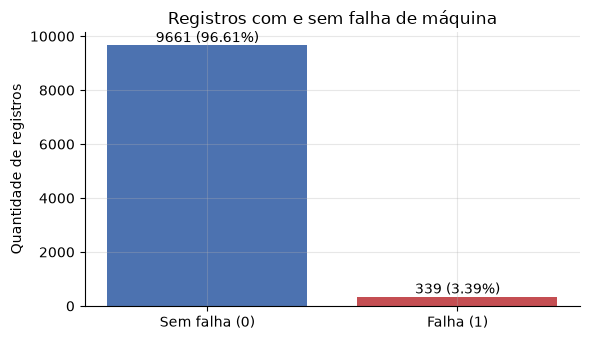

In [5]:
contagem = df["Machine failure"].value_counts().sort_index()
pct = df["Machine failure"].value_counts(normalize=True).sort_index() * 100
taxa = pd.DataFrame({"registros": contagem, "percentual (%)": pct.round(2)})
taxa.index = ["Sem falha (0)", "Falha (1)"]
display(taxa)

fig, ax = plt.subplots(figsize=(6, 3.5))
barras = ax.bar(taxa.index, taxa["registros"], color=[COR_OK, COR_FALHA])
for b, n, p in zip(barras, taxa["registros"], taxa["percentual (%)"]):
    ax.text(b.get_x() + b.get_width() / 2, n, f"{n} ({p:.2f}%)", ha="center", va="bottom")
ax.set_title("Registros com e sem falha de máquina")
ax.set_ylabel("Quantidade de registros")
plt.tight_layout()
plt.show()

**Leitura:** a classe "falha" é **rara** (desbalanceamento forte). Isso tem três consequências práticas para os próximos passos:

- **Acurácia engana**: um modelo que nunca prevê falha já teria uma acurácia altíssima. Vamos olhar *recall* (quantas falhas o modelo pega), *precisão* e F1.
- A divisão treino/teste precisa ser **estratificada**, para as poucas falhas aparecerem nos dois lados na mesma proporção.
- No treino será preciso compensar o desbalanceamento (por exemplo, com peso maior para a classe falha).

### Falha por tipo de produto

A coluna `Type` indica a variante/qualidade do produto: **L** (baixa), **M** (média) e **H** (alta).

,registros,falhas,taxa_falha (%)
Type,,,
L,6000,235,3.92
M,2997,83,2.77
H,1003,21,2.09


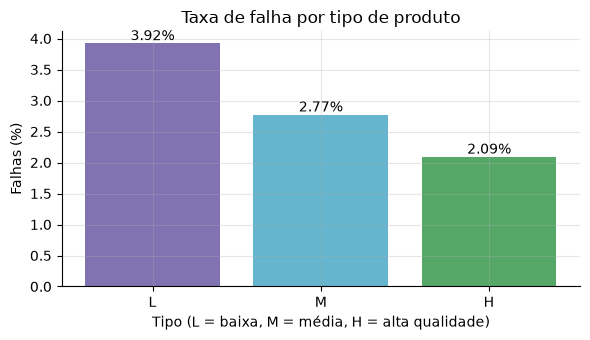

In [6]:
por_tipo = (df.groupby("Type")["Machine failure"]
              .agg(registros="count", falhas="sum", taxa_falha="mean")
              .reindex(["L", "M", "H"]))
por_tipo["taxa_falha (%)"] = (por_tipo.pop("taxa_falha") * 100).round(2)
display(por_tipo)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(por_tipo.index, por_tipo["taxa_falha (%)"], color=["#8172B2", "#64B5CD", "#55A868"])
for i, v in enumerate(por_tipo["taxa_falha (%)"]):
    ax.text(i, v, f"{v:.2f}%", ha="center", va="bottom")
ax.set_title("Taxa de falha por tipo de produto")
ax.set_xlabel("Tipo (L = baixa, M = média, H = alta qualidade)")
ax.set_ylabel("Falhas (%)")
plt.tight_layout()
plt.show()

## 4. Os sensores contam uma história diferente quando há falha?

Abaixo, a distribuição de cada sensor separada entre registros **sem falha** (azul) e **com falha** (vermelho).
Como existem muito mais registros sem falha, os histogramas estão **normalizados** (densidade): assim dá para comparar o *formato* das duas curvas, e não o tamanho.

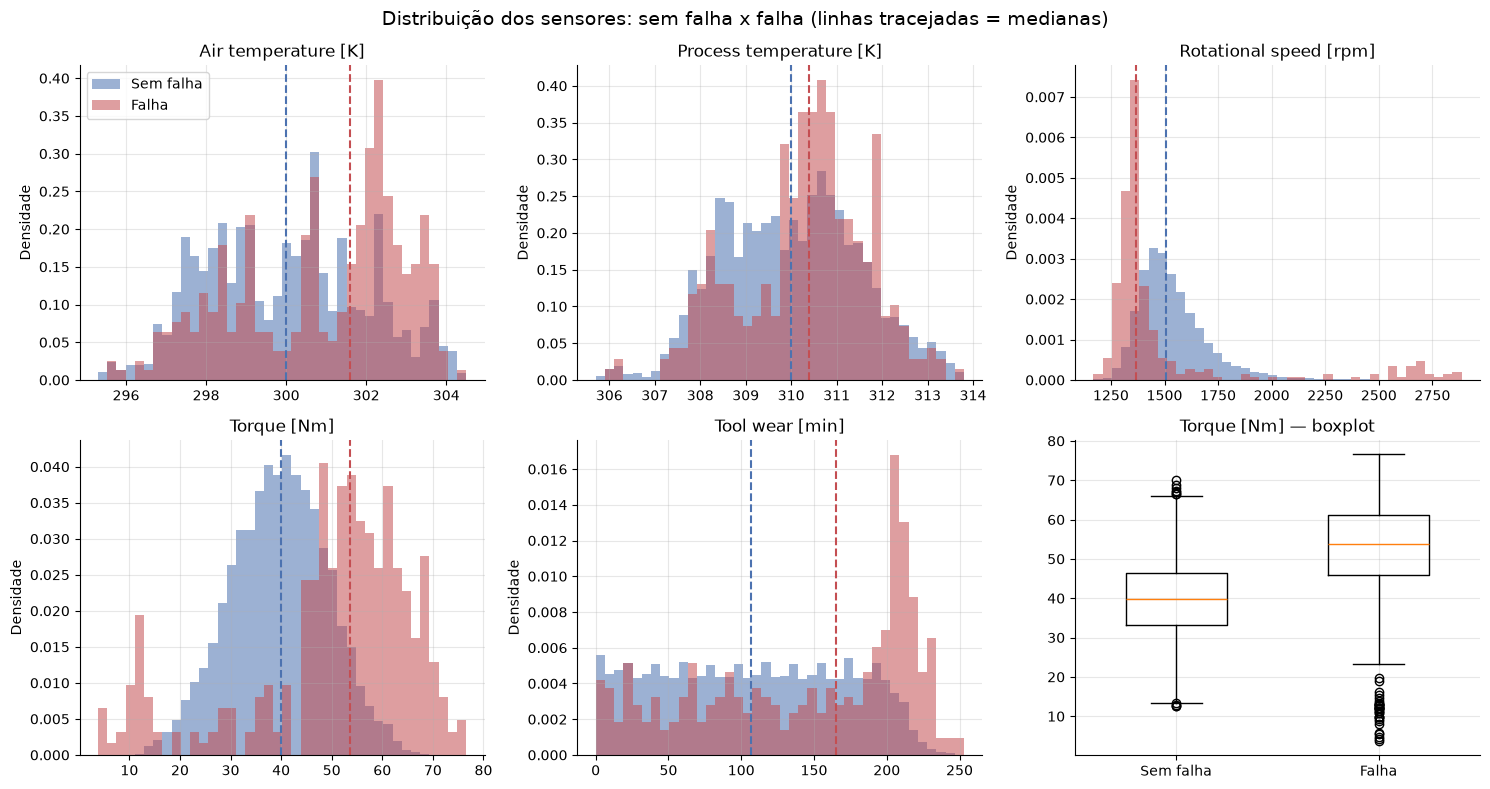

In [7]:
falha = df["Machine failure"] == 1
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, SENSORES):
    bins = np.histogram_bin_edges(df[col], bins=40)
    ax.hist(df.loc[~falha, col], bins=bins, density=True, alpha=0.55, color=COR_OK, label="Sem falha")
    ax.hist(df.loc[falha, col], bins=bins, density=True, alpha=0.55, color=COR_FALHA, label="Falha")
    ax.axvline(df.loc[~falha, col].median(), color=COR_OK, ls="--", lw=1.5)
    ax.axvline(df.loc[falha, col].median(), color=COR_FALHA, ls="--", lw=1.5)
    ax.set_title(col)
    ax.set_ylabel("Densidade")
axes.flat[0].legend()

# Último quadro: boxplot do torque, a variável mais separada visualmente
ax = axes.flat[-1]
ax.boxplot([df.loc[~falha, "Torque [Nm]"], df.loc[falha, "Torque [Nm]"]], widths=0.5)
ax.set_xticks([1, 2], ["Sem falha", "Falha"])
ax.set_title("Torque [Nm] — boxplot")
fig.suptitle("Distribuição dos sensores: sem falha x falha (linhas tracejadas = medianas)", fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
comparacao = df.groupby("Machine failure")[SENSORES].median().T
comparacao.columns = ["Mediana sem falha", "Mediana com falha"]
comparacao["Diferença"] = comparacao["Mediana com falha"] - comparacao["Mediana sem falha"]
comparacao

,Mediana sem falha,Mediana com falha,Diferença
Air temperature [K],300.0,301.6,1.6
Process temperature [K],310.0,310.4,0.4
Rotational speed [rpm],1507.0,1365.0,-142.0
Torque [Nm],39.9,53.7,13.8
Tool wear [min],107.0,165.0,58.0


**Leitura (visão de manutenção):**

- **Torque** e **desgaste da ferramenta** são os sinais mais claros: nas falhas, a máquina geralmente está fazendo mais força e a ferramenta está mais gasta (o pico vermelho do desgaste fica pouco acima de 200 min). O torque também mostra um pequeno grupo de falhas com torque **muito baixo** (em torno de 10 Nm) — são casos de potência baixa demais, que aparecem no gráfico torque x rotação mais abaixo.
- **Rotação**: as falhas se concentram nas pontas — rotação baixa (típico de torque alto) e alguns casos de rotação muito alta. A distribuição vermelha é mais "espalhada".
- **Temperaturas**: diferença pequena na mediana, mas a temperatura do ar um pouco mais alta nas falhas sugere problema de **dissipação de calor**.

### Desgaste da ferramenta: existe um "ponto de troca"?

Quem já trabalhou com usinagem sabe que ferramenta tem vida útil. Vamos comparar a taxa de falha antes e depois de 200 minutos de uso.

In [9]:
desgaste_alto = df["Tool wear [min]"] > 200
tabela_desgaste = (df.groupby(desgaste_alto)["Machine failure"]
                     .agg(registros="count", falhas="sum", taxa="mean"))
tabela_desgaste.index = ["Até 200 min", "Acima de 200 min"]
tabela_desgaste["taxa (%)"] = (tabela_desgaste.pop("taxa") * 100).round(2)
tabela_desgaste

,registros,falhas,taxa (%)
Até 200 min,9238,221,2.39
Acima de 200 min,762,118,15.49


### Torque x rotação: a "janela" de operação

Torque e rotação juntos definem a **potência mecânica** no eixo: $P = \tau \cdot \omega$ (com $\omega$ em rad/s = rpm × 2π/60).
O gráfico mostra cada registro nesse plano; as falhas (vermelho) se acumulam nas bordas da nuvem.

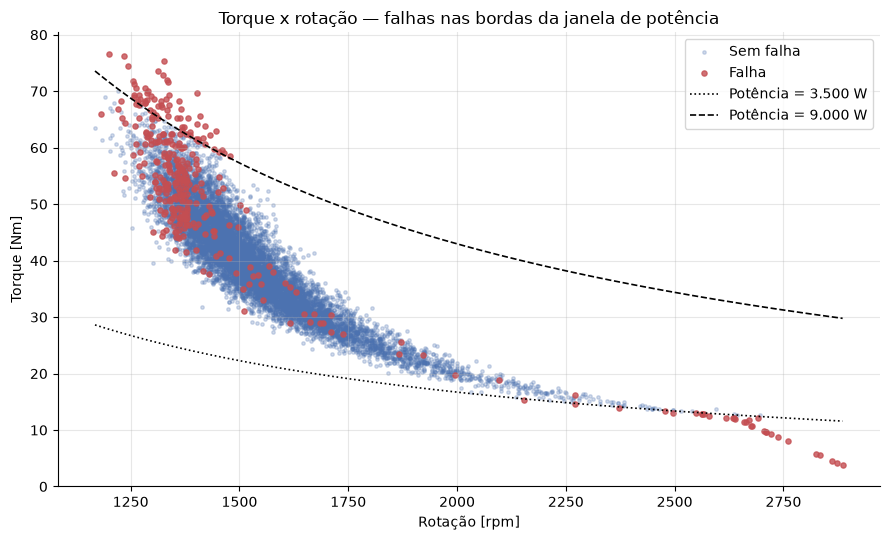

Registros com potência fora de 3.500–9.000 W: 95
Desses, com falha: 95 (100%)


In [10]:
potencia_w = df["Torque [Nm]"] * df["Rotational speed [rpm]"] * 2 * np.pi / 60

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(df.loc[~falha, "Rotational speed [rpm]"], df.loc[~falha, "Torque [Nm]"],
           s=6, alpha=0.25, color=COR_OK, label="Sem falha")
ax.scatter(df.loc[falha, "Rotational speed [rpm]"], df.loc[falha, "Torque [Nm]"],
           s=14, alpha=0.8, color=COR_FALHA, label="Falha")
# Curvas de potência constante (3.500 W e 9.000 W) para referência
rpm = np.linspace(df["Rotational speed [rpm]"].min(), df["Rotational speed [rpm]"].max(), 200)
for p, estilo in [(3500, ":"), (9000, "--")]:
    ax.plot(rpm, p / (rpm * 2 * np.pi / 60), "k", ls=estilo, lw=1.2, label=f"Potência = {p:,} W".replace(",", "."))
ax.set_ylim(0, df["Torque [Nm]"].max() * 1.05)
ax.set_xlabel("Rotação [rpm]")
ax.set_ylabel("Torque [Nm]")
ax.set_title("Torque x rotação — falhas nas bordas da janela de potência")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

fora_janela = (potencia_w < 3500) | (potencia_w > 9000)
print(f"Registros com potência fora de 3.500–9.000 W: {int(fora_janela.sum())}")
print(f"Desses, com falha: {int(df.loc[fora_janela, 'Machine failure'].sum())} "
      f"({df.loc[fora_janela, 'Machine failure'].mean():.0%})")

## 5. Modos de falha: *por que* a máquina falhou?

O dataset informa também **qual mecanismo** causou cada falha:

| Sigla | Nome | Em termos de fábrica |
|---|---|---|
| **TWF** | Tool Wear Failure | Ferramenta chegou ao fim da vida útil |
| **HDF** | Heat Dissipation Failure | Calor não está sendo dissipado (pouca diferença ar/processo com rotação baixa) |
| **PWF** | Power Failure | Potência fora da faixa de trabalho (baixa ou alta demais) |
| **OSF** | Overstrain Failure | Sobrecarga: ferramenta gasta + torque alto |
| **RNF** | Random Failure | Falha aleatória, sem relação com o processo |

,ocorrências
HDF,115
OSF,98
PWF,95
TWF,46
RNF,19


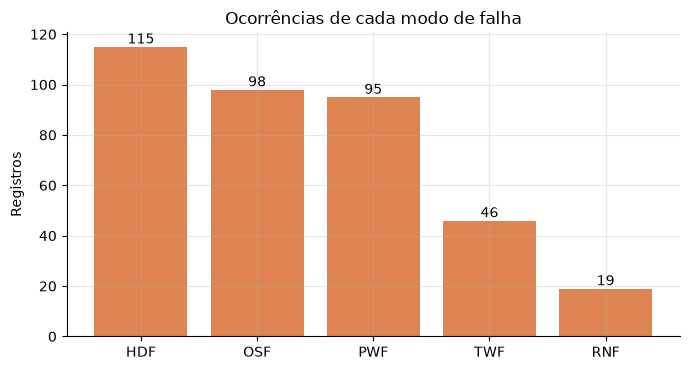

In [11]:
MODOS = ["TWF", "HDF", "PWF", "OSF", "RNF"]
modos = df[MODOS].sum().sort_values(ascending=False)
display(modos.to_frame("ocorrências"))

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.bar(modos.index, modos.values, color="#DD8452")
for i, v in enumerate(modos.values):
    ax.text(i, v, str(v), ha="center", va="bottom")
ax.set_title("Ocorrências de cada modo de falha")
ax.set_ylabel("Registros")
plt.tight_layout()
plt.show()

In [12]:
n_modos = df[MODOS].sum(axis=1)
print(f"Soma das ocorrências de modos: {int(modos.sum())} (maior que o total de falhas: {int(df['Machine failure'].sum())})")
print(f"Registros com mais de um modo ao mesmo tempo: {int((n_modos > 1).sum())}")
print(f"Falhas (Machine failure = 1) sem nenhum modo marcado: {int(((df['Machine failure'] == 1) & (n_modos == 0)).sum())}")
sem_rotulo = (df["Machine failure"] == 0) & (n_modos > 0)
print(f"Registros com modo marcado mas Machine failure = 0: {int(sem_rotulo.sum())} "
      f"-> modos: {df.loc[sem_rotulo, MODOS].sum()[lambda s: s > 0].to_dict()}")

Soma das ocorrências de modos: 373 (maior que o total de falhas: 339)
Registros com mais de um modo ao mesmo tempo: 24
Falhas (Machine failure = 1) sem nenhum modo marcado: 9
Registros com modo marcado mas Machine failure = 0: 18 -> modos: {'RNF': 18}


**Leitura:**

- **HDF** (dissipação de calor) é o modo mais comum, seguido de sobrecarga (OSF) e potência (PWF).
- Um mesmo registro pode ter **mais de um modo** ao mesmo tempo — por isso a soma dos modos passa do total de falhas.
- Há pequenas **inconsistências de rotulagem**: algumas falhas sem modo informado e alguns registros com `RNF = 1` mas sem falha marcada. É um lembrete de que até dataset "limpo" tem ruído; como são poucos casos, o alvo `Machine failure` será usado como está.
- Os números acima **não batem** com os citados no texto descritivo do UCI (que fala, por exemplo, em 120 casos de TWF e 5 de RNF). Neste projeto valem os números calculados no próprio arquivo.

### Atenção: modos de falha são "a resposta"

Os modos de falha só são conhecidos **depois** que a máquina quebra — é o laudo da manutenção. Se entrassem no modelo como variáveis de entrada, ele simplesmente "leria a resposta":

In [13]:
algum_modo = (df[MODOS].max(axis=1) == 1).astype(int)
concordancia = (algum_modo == df["Machine failure"]).mean()
print(f"'Tem algum modo marcado' coincide com 'Machine failure' em {concordancia:.2%} dos registros.")

'Tem algum modo marcado' coincide com 'Machine failure' em 99.73% dos registros.


Isso é **vazamento de alvo** (*data leakage*): o modelo pareceria quase perfeito no teste, mas seria inútil na linha de produção, onde queremos o alerta **antes** da falha.
Por isso, na preparação (`src/features.py`), as colunas `TWF`, `HDF`, `PWF`, `OSF` e `RNF` são **removidas** das variáveis de entrada.

## 6. Correlação entre variáveis

A correlação (de −1 a +1) mostra quanto duas variáveis variam juntas **de forma linear**.
Incluo também duas grandezas físicas derivadas, que serão criadas na preparação: **potência** (W) e **diferença de temperatura** processo − ar (K).

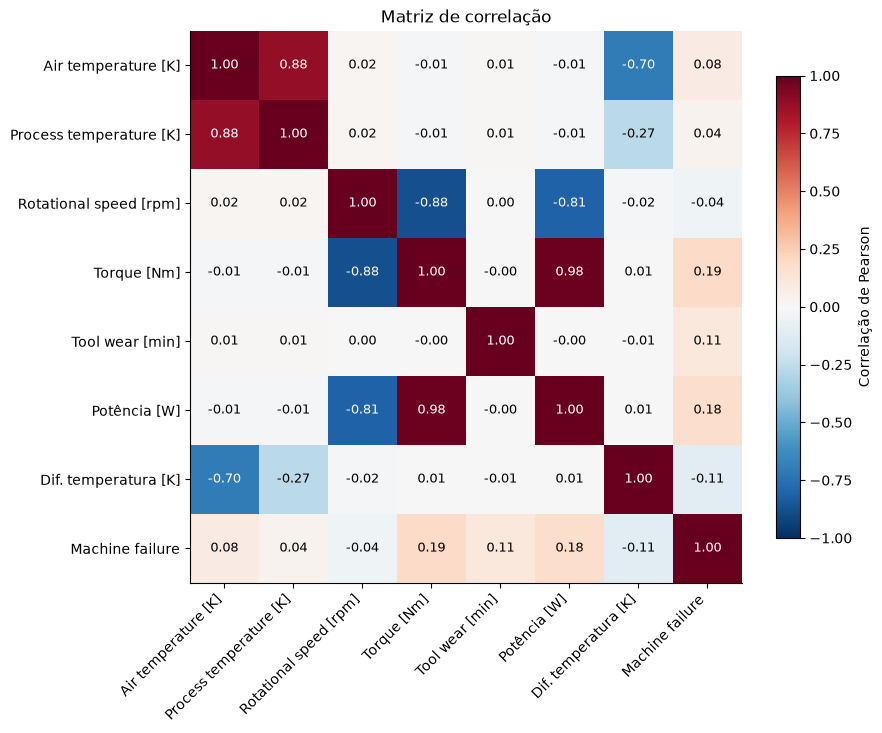

,correlação com falha
Torque [Nm],0.19
Potência [W],0.18
Dif. temperatura [K],-0.11
Tool wear [min],0.11
Air temperature [K],0.08
Rotational speed [rpm],-0.04
Process temperature [K],0.04


In [14]:
corr_df = df[SENSORES + ["Machine failure"]].copy()
corr_df["Potência [W]"] = potencia_w
corr_df["Dif. temperatura [K]"] = df["Process temperature [K]"] - df["Air temperature [K]"]
ordem = SENSORES + ["Potência [W]", "Dif. temperatura [K]", "Machine failure"]
corr = corr_df[ordem].corr()

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(ordem)), ordem, rotation=45, ha="right")
ax.set_yticks(range(len(ordem)), ordem)
ax.grid(False)
for i in range(len(ordem)):
    for j in range(len(ordem)):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9,
                color="white" if abs(v) > 0.6 else "black")
fig.colorbar(im, ax=ax, shrink=0.8, label="Correlação de Pearson")
ax.set_title("Matriz de correlação")
plt.tight_layout()
plt.show()

corr["Machine failure"].drop("Machine failure").sort_values(key=abs, ascending=False).to_frame("correlação com falha")

**Leitura:**

- **Rotação x torque** têm correlação forte e negativa: a máquina trabalha perto de uma potência constante, então quando a rotação sobe o torque cai (e vice-versa).
- **Temperatura do ar x temperatura de processo** também são fortemente ligadas — o processo "acompanha" o ambiente.
- Nenhuma variável sozinha tem correlação alta com a falha. O **torque** é a mais correlacionada, seguido de potência, diferença de temperatura e desgaste.
  Isso é esperado: as falhas acontecem por **combinações** de condições (ex.: ferramenta gasta **e** torque alto; rotação baixa **e** pouca diferença de temperatura), relações não lineares que modelos de árvore como o **XGBoost** capturam bem.

## 7. Conclusões da exploração

In [15]:
# Números-chave calculados para a conclusão
n_linhas = len(df)
n_falhas = int(df["Machine failure"].sum())
print(f"Registros: {n_linhas} | Falhas: {n_falhas} ({n_falhas / n_linhas:.2%})")
print("Modos de falha:", df[MODOS].sum().to_dict())
print("Taxa de falha por tipo (%):", (df.groupby("Type")["Machine failure"].mean() * 100).round(2).to_dict())
print("Mediana do torque (sem falha / falha):", df.groupby("Machine failure")["Torque [Nm]"].median().tolist())
print("Mediana do desgaste (sem falha / falha):", df.groupby("Machine failure")["Tool wear [min]"].median().tolist())

Registros: 10000 | Falhas: 339 (3.39%)
Modos de falha: {'TWF': 46, 'HDF': 115, 'PWF': 95, 'OSF': 98, 'RNF': 19}
Taxa de falha por tipo (%): {'H': 2.09, 'L': 3.92, 'M': 2.77}
Mediana do torque (sem falha / falha): [39.9, 53.7]
Mediana do desgaste (sem falha / falha): [107.0, 165.0]


1. **Dados completos**: 10.000 registros, 14 colunas, **zero** valores faltantes e **zero** duplicados.
2. **Falha é evento raro**: **339 falhas (3,39%)** contra 9.661 registros sem falha. O modelo precisa ser avaliado por recall/precisão/F1, com divisão estratificada e compensação do desbalanceamento.
3. **Sinais mais fortes**: nas falhas, a mediana do **torque** sobe de 39,9 para 53,7 Nm e a do **desgaste da ferramenta** de 107 para 165 min. Com a ferramenta acima de 200 min de uso, a taxa de falha vai de 2,39% para **15,49%** — mais de 6 vezes maior.
4. **Janela de potência**: todos os 95 registros com potência fora da faixa 3.500–9.000 W falharam (100%) — a potência calculada (torque × rotação) é uma variável com forte significado físico.
5. **Tipo de produto importa**: taxa de falha de 3,92% no tipo L, 2,77% no M e 2,09% no H.
6. **Modos de falha**: HDF 115, OSF 98, PWF 95, TWF 46 e RNF 19. Essas colunas **vazam o alvo** e serão removidas das entradas do modelo.
7. **Relações não lineares**: nenhuma variável isolada explica a falha (maior correlação: torque, 0,19). Faz sentido usar um modelo de árvores (XGBoost) e criar variáveis físicas (potência e diferença de temperatura).

**Próximo passo:** preparar os dados para o modelo — ver [`02_preparacao.ipynb`](02_preparacao.ipynb).